In [1]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
os.listdir()

['dataset', 'phase1.ipynb']

In [7]:
import os

print(os.getcwd())

/home/sahil/SynthMicro


In [ ]:
dataset_path="../dataset"


In [10]:
classes = sorted(os.listdir(dataset_path))

print(classes)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


In [11]:
image_counts = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    image_counts[cls] = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

image_counts

{'basophil': 1000,
 'erythroblast': 1000,
 'monocyte': 1000,
 'myeloblast': 1000,
 'seg_neutrophil': 1000}

In [12]:
summary = pd.DataFrame(
    image_counts.items(),
    columns=["Class","Images"]
)
summary

,Class,Images
0,basophil,1000
1,erythroblast,1000
2,monocyte,1000
3,myeloblast,1000
4,seg_neutrophil,1000


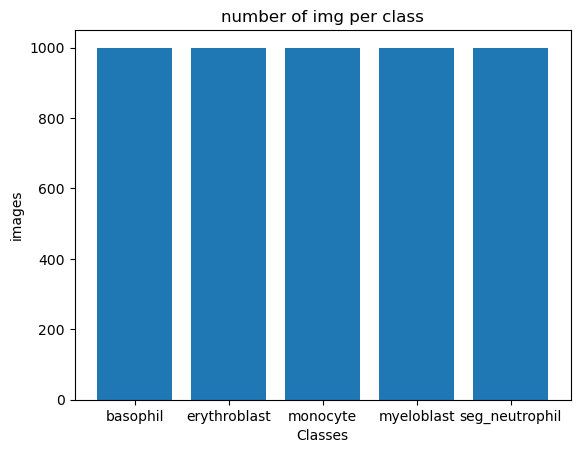

In [13]:
plt.bar(summary["Class"],summary["Images"])
plt.title("number of img per class")
plt.ylabel("images")
plt.xlabel("Classes")
plt.show()

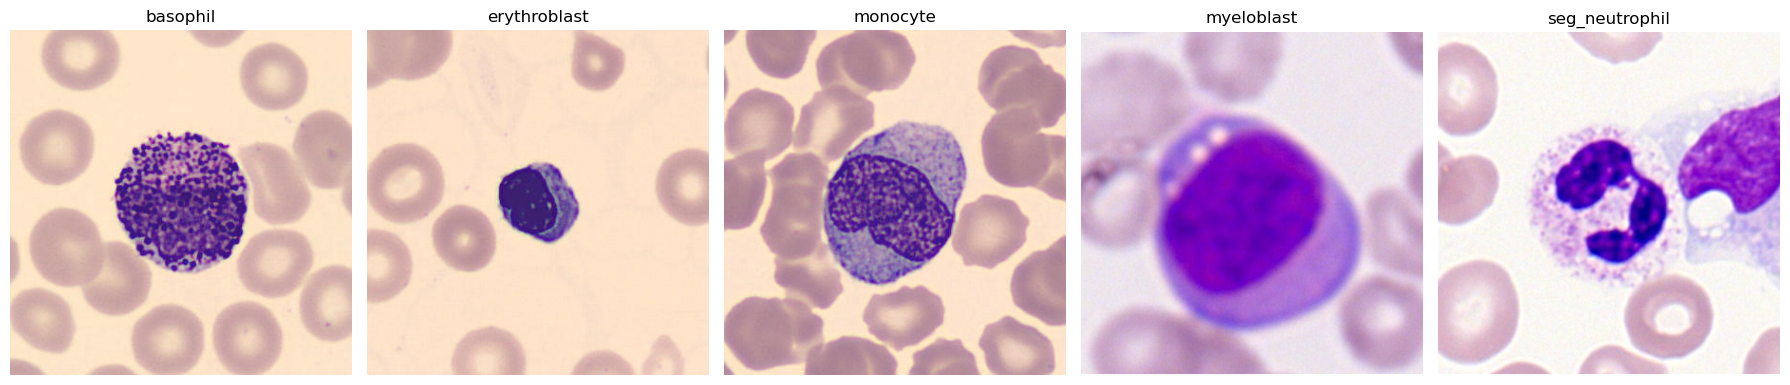

In [14]:
fig, axes = plt.subplots(1, len(classes), figsize=(18,4))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    img_name = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder, img_name))

    axes[i].imshow(img)

    axes[i].set_title(cls)

    axes[i].axis("off")

plt.tight_layout()

plt.show()

In [15]:
sizes = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        img = Image.open(os.path.join(folder, file))

        sizes.append(img.size)

print("Unique Sizes:", set(sizes))

Unique Sizes: {(366, 369), (360, 360), (400, 400), (360, 363)}


In [16]:
img = Image.open(os.path.join(dataset_path,
                              classes[0],
                              os.listdir(os.path.join(dataset_path, classes[0]))[0]))

print(img.mode)

RGB


In [17]:
bad_images = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        try:
            Image.open(os.path.join(folder, file)).verify()

        except:
            bad_images.append(file)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0
